In [1]:
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np


def plot(categories, results, stages):
    data = np.array(results)
    data_cum = data.cumsum(axis=-1)
    data_max = data_cum[..., -1].max(axis=-1)
    colors = plt.colormaps['Blues'](np.linspace(0.7, 0.3, data.shape[-1]))

    fig, axes = plt.subplots(data.shape[0], 1, figsize=(10, 7.5), dpi=600)
    height = 0.2
    y = (height + 0.05) * np.arange(data.shape[-2]) + height / 2 + 0.25
    width = 0.25
    multiplier = 0
    for k in range(data.shape[0]):
        axes[k].set_xlim(0, 1)
        axes[k].set_ylim(0, 1)
        axes[k].get_xaxis().set_ticks([0.0] + [v / data_max[k] for v in data_cum[k, :, -1]])
        axes[k].set_xticklabels([0.0] + [f"{v:.1f}" for v in data_cum[k, :, -1]])
        labels = [f"{0:.1f}"] + [f"{v:.1f}" for v in data_cum[k, :, -1]]
        if k == 0:
            labels[0] = "    " + labels[0]
            labels[1] = labels[1] + "      "
            labels[2] = "    " + labels[2]
            labels[3] = labels[3] + "    "
        else:
            labels[0] = "    " + labels[0]
            labels[1] = labels[1] + "        "
        axes[k].set_xticklabels(labels)
        axes[k].get_yaxis().set_ticks([])
        for i, spine in enumerate(axes[k].spines.values()):
            if i != 2:
                spine.set_visible(False)
            else:
                spine.set_linewidth(2)
        axes[k].tick_params(axis='both', which='major', labelsize=18, width=2)
        axes[k].invert_yaxis()

        for i, (stage, color) in enumerate(zip(stages, colors)):
            widths = data[k, :, i]  / data_max[k]
            starts = data_cum[k, :, i] / data_max[k] - widths

            offset = width * multiplier
            rects = axes[k].barh(
                y + offset, widths, left=starts, height=height,
                label=stage, color=color, edgecolor = "None" if i != 2 else "tomato", zorder = 0 if i != 2 else 10, linewidth = 0 if i != 2 else 1.5)
            # if i == 0:
            #     axes[k].bar_label(
            #         rects, labels=["LoFTR", "ELoFTR", "Ours"], label_type='edge', 
            #         fontsize=16, fontfamily='serif')

        widths = 1 - data_cum[k, :, -1] / data_max[k]
        starts = data_cum[k, :, -1] / data_max[k]
        offset = width * multiplier
        rects = axes[k].barh(
            y + offset, widths, left=starts, height=height,
            label=stage, color='lightpink')
        labels = [f"-{100 * widths[s]:.2f}%" for s in range(len(widths))]
        labels[labels == 0] = ""
        axes[k].bar_label(
            rects, labels=labels, label_type='center', 
            fontsize=22, fontfamily='sans-serif', fontstyle='italic',
            fontweight='bold', color="white")

        # rects = ax.barh(
        #     y + offset + 1 * k, [0.0 for _ in range(len(widths))], left=[1.0 for _ in range(len(widths))], height=height,
        #     label=stage, color='lightpink')
        # ax.bar_label(
        #     rects, labels=[f"{data_cum[k, s, -1]:.2f}" for s in range(len(widths))], padding=0.5, fontsize=20, fontfamily='serif', fontweight='light')

    axes[0].legend(
        ["", "", "", "", "Matching Stages    ", "Remain"], ncols=len(stages) + 1, 
        bbox_to_anchor=(-0.01, 1), loc='lower left', columnspacing=-0.1, 
        fontsize=18)

    for k in range(data.shape[0]):
        widths = [0.0 for _ in range(len(widths))]
        starts = [0.0 for _ in range(len(widths))]
        offset = width * multiplier
        rects = axes[k].barh(
            y + offset, widths, left=starts, height=height,
            label=stage, color='none')
        labels = ["LoFTR", "ELoFTR", "Ours"]
        axes[k].bar_label(
            rects, labels=labels, label_type='edge', 
            fontsize=18, fontfamily='serif')

        offset = width * multiplier
        rects = axes[k].barh(
            y[0] + offset - 0.25, [1.0], left=[0.0], 
            height=height, color="white")
        axes[k].bar_label(
            rects, labels=[categories[k]], label_type='center', fontsize=20, fontfamily='serif')
    axes[-1].set_xlabel(
        'Runtime (ms) aligned to LoFTR using FP32', fontsize=20,
        fontfamily='serif')

stages = [
    'Backbone',
    'Coarse Interaction',
    'Coarse Matching',
    'Fine Interaction',
    'Fine Matching'
]

categories = [f"{s}" for s in [r"640$\times$480 (ScanNet-1500)", r"832$\times$832 (MegaDepth-1500)", r"1152$\times$1152 (MegaDepth-1500)"]]

results = [
    [
        [32.11, 19.26, 11.42, 8.60, 0.33],
        [10.72, 10.96, 11.64, 9.79, 2.06],
        [8.20, 9.17, 11.06, 6.96, 4.67]
        # [5.49, 11.93, 7.14, 3.42, 4.33] 32.3
    ],
    [
        [71.56, 44.55, 37.72, 15.00, 0.2],
        [23.83, 19.69, 38.72, 20.27, 2.05],
        [20.87, 13.82, 25.89, 15.04, 5.90]
        # [17.89, 13.14, 22.33, 10.55, 5.55] 69.47
    ],
    [
        [135.50, 82.26, 103.09, 26.53, 0.19],
        [43.23, 41.04, 107.12, 44.41, 2.48],
        [31.13, 23.44, 55.03, 29.16, 8.40]
        # [20.02, 13.66, 29.53, 13.78, 6.75] 83.74
    ]
]

plot(categories, results, stages)
if False:
    plt.show()
else:
    plt.savefig(
        r"C:\Users\LinKInLeLe43\Desktop\teaser.pdf",
        bbox_inches='tight', pad_inches=0.05)
    plt.close()

[0. 1. 2.]
(18.35, 18.43, 14.98)
[0.25 1.25 2.25]
(38.79, 48.83, 47.5)
[0.5 1.5 2.5]
(189.95, 195.82, 217.19)


TypeError: bad operand type for unary -: 'tuple'

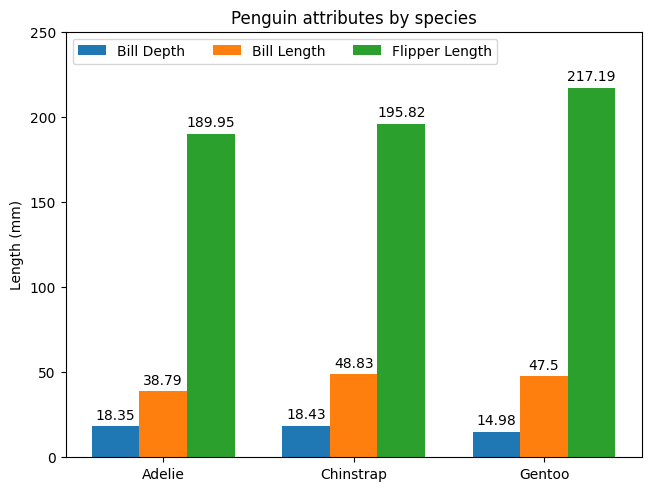

In [501]:
import matplotlib.pyplot as plt
import numpy as np

species = ("Adelie", "Chinstrap", "Gentoo")
penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}

x = np.arange(len(species))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    print(x + offset)
    print(measurement)
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 250)

plt.savefig(r"C:\Users\LinKInLeLe43\Desktop\output.pdf", bbox_inches='tight', pad_inches=0)
plt.close()

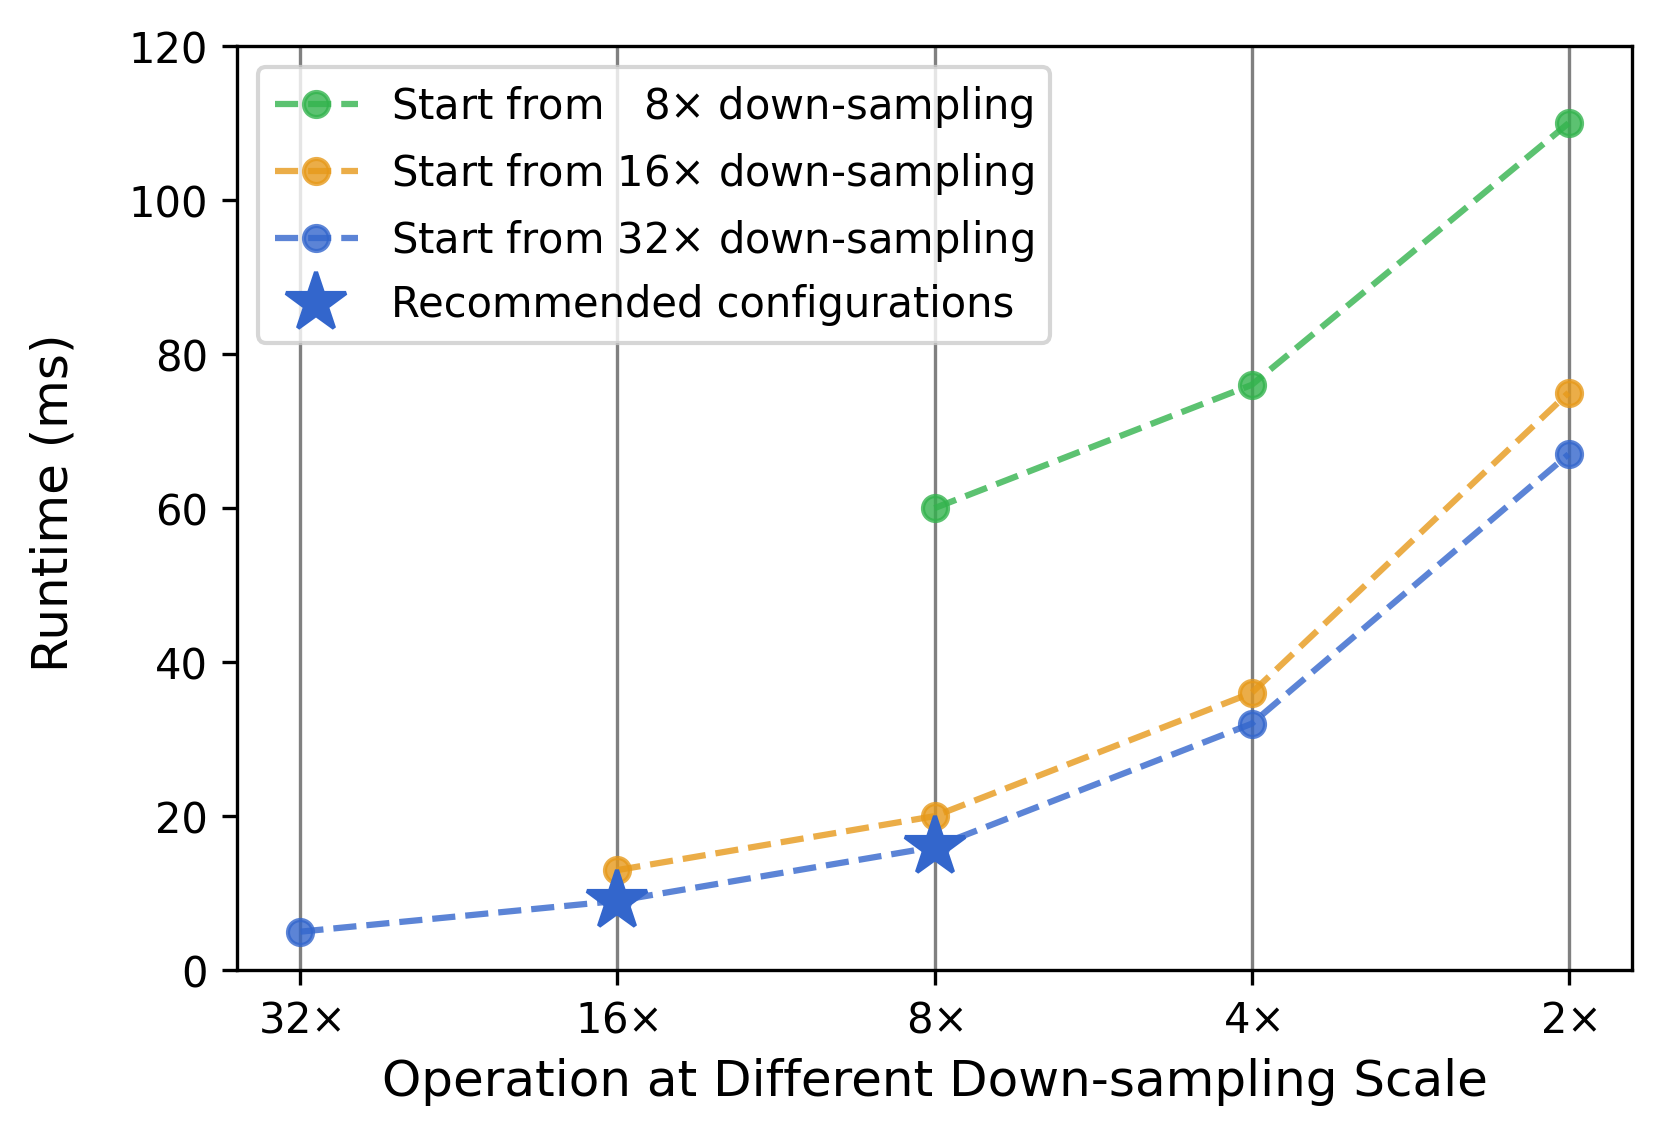

In [116]:
import matplotlib.pyplot as plt
import numpy as np

x0 = np.arange(5)
x1 = np.arange(1, 5)
x2 = np.arange(2, 5)

y0 = np.array([5, 9, 16, 32, 67]) # 32x 16 8x 4x 2x
y1 = np.array([13, 20, 36, 75]) # 16x 8x 4x 2x
y2 = np.array([60, 76, 110]) # 8x 4x 2x

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)

ax.plot(x2, y2, 'o--', color=(0.2, 0.7, 0.3, 0.8), label="Start from   8"r"$\times$ down-sampling")
ax.plot(x1, y1, 'o--', color=(0.9, 0.6, 0.1, 0.8), label="Start from 16"r"$\times$ down-sampling")
ax.plot(x0, y0, 'o--', color=(0.2, 0.4, 0.8, 0.8), label="Start from 32"r"$\times$ down-sampling")
ax.plot(x0[1:3], y0[1:3], '*', color=(0.2, 0.4, 0.8, 1.0), markersize=15, label="Recommended configurations")

ax.set_ylim(0, 120)  # 上子图范围：28.9附近
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(["32"r"$\times$", "16"r"$\times$", "8"r"$\times$", "4"r"$\times$", "2"r"$\times$"])

ax.set_xlabel('Operation at Different Down-sampling Scale', fontsize=12)
fig.text(0.01, 0.5, "Runtime (ms)", va='center', rotation='vertical', fontsize=12)

ax.legend(loc="upper left")

plt.grid(axis='x', color='0.5')
# plt.title('plt.step(where=...)')
plt.savefig(r"C:\Users\LinKInLeLe43\Desktop\gaofen_runtime.pdf", bbox_inches='tight')

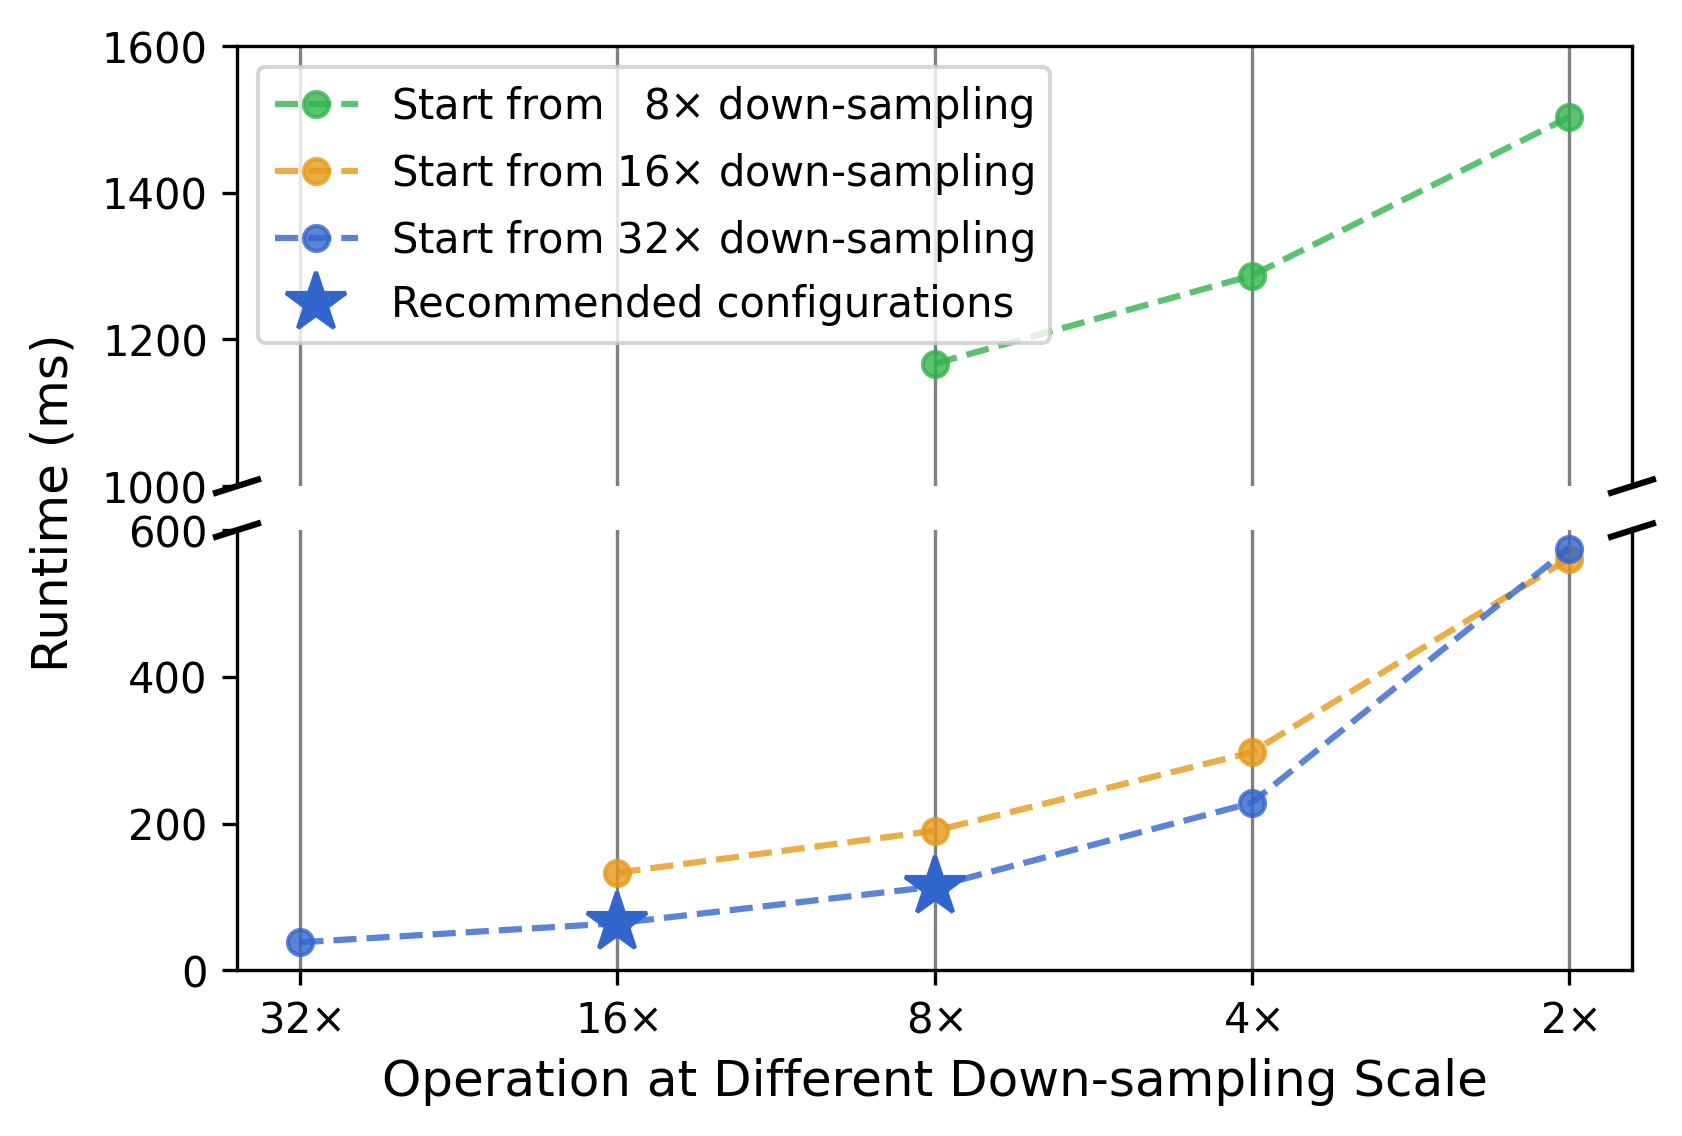

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
x0 = np.arange(5)
x1 = np.arange(1, 5)
x2 = np.arange(2, 5)

y0 = np.array([38, 64, 114, 228, 575])  # 32x 16 8x 4x 2x
y1 = np.array([133, 190, 297, 561])  # 16x 8x 4x 2x
y2 = np.array([1167, 1287, 1503])  # 8x 4x 2x

# 创建带有断轴的子图
fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 4), dpi=300)
fig.subplots_adjust(hspace=0.1)  # 调整上下子图间距

# 绘制数据
ax.plot(x2, y2, 'o--', color=(0.2, 0.7, 0.3, 0.8), label="Start from   8"r"$\times$ down-sampling")
ax.plot(x1, y1, 'o--', color=(0.9, 0.6, 0.1, 0.8), label="Start from 16"r"$\times$ down-sampling")
ax.plot(x0, y0, 'o--', color=(0.2, 0.4, 0.8, 0.8), label="Start from 32"r"$\times$ down-sampling")
ax.plot(x0[1:3], y0[1:3], '*', color=(0.2, 0.4, 0.8, 1.0), markersize=15, label="Recommended configurations")
ax2.plot(x2, y2, 'o--', color=(0.2, 0.7, 0.3, 0.8))
ax2.plot(x1, y1, 'o--', color=(0.9, 0.6, 0.1, 0.8))
ax2.plot(x0, y0, 'o--', color=(0.2, 0.4, 0.8, 0.8))
ax2.plot(x0[1:3], y0[1:3], '*', color=(0.2, 0.4, 0.8, 1.0), markersize=15, label="Recommended configurations")


# 设置 y 轴范围
ax.set_ylim(1000, 1600)  # 上子图范围：28.9附近
ax2.set_ylim(0, 600)  # 下子图范围：低值范围

# ** 隐藏上图的 x 轴刻度和标签 **
ax.tick_params(bottom=False, top=False, labelbottom=False)  # 隐藏上图的 x 轴刻度和标签

# 添加断轴指示器
ax.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_xticklabels(["32"r"$\times$", "16"r"$\times$", "8"r"$\times$", "4"r"$\times$", "2"r"$\times$"])

# 绘制断轴标志
d = 0.015  # 断轴标志的大小
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
ax.plot((-d, +d), (-d, +d), **kwargs)        # 上断轴
ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # 上断轴
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # 下断轴
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # 下断轴

# 设置 x 轴和 y 轴标签
ax2.set_xlabel('Operation at Different Down-sampling Scale', fontsize=12)
fig.text(0.01, 0.5, "Runtime (ms)", va='center', rotation='vertical', fontsize=12)
# fig.text(0.43, 0.28, "Performance", fontsize=12)
# fig.text(0.55, 0.17, "Efficiency", fontsize=12)
# 添加图例
ax.legend(loc="upper left")
ax.grid(axis='x', color='0.5')
ax2.grid(axis='x', color='0.5')
# 显示图表
plt.savefig(r"C:\Users\LinKInLeLe43\Desktop\superview_runtime.pdf", bbox_inches='tight')